# Analyse Exploratoire des Données de Méthylation ADN

Exploration des niveaux de méthylation en fonction de l'âge et du sexe :
1. Moyenne et variance des niveaux de méthylation par âge et sexe
2. Distribution des niveaux de méthylation par âge et sexe
3. Distribution des corrélations avec l'âge, comparaison par sexe
4. Réduction de dimension (PCA, t-SNE, UMAP) pour visualiser les patterns liés à l'âge et au sexe

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
from time import time

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print('UMAP non disponible, sera ignoré.')

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path('Data')
CHUNK_SIZE = 5000
TOP_K = 500

print('Imports OK')

Imports OK


## Chargement des Données

Les données de méthylation (894K CpG x 400 échantillons) sont trop volumineuses pour être chargées en mémoire.
On calcule les statistiques par chunks et on charge uniquement les top-500 CpG pour les analyses détaillées.

In [4]:
# --- Annotations ---
ind = pd.read_csv(DATA_DIR / 'annot_projet.csv')
ind = ind.dropna(subset=['age', 'Sample_description']).copy()
ind['Sample_description'] = ind['Sample_description'].astype(str)
ind['sexe'] = ind['female'].apply(lambda x: 'F' if str(x).upper() == 'TRUE' else 'M')
ind['age_group'] = pd.cut(ind['age'], bins=[0, 30, 50, 70, 100], labels=['<30', '30-50', '50-70', '>70'])
ind = ind.set_index('Sample_description')

# --- Identifier les échantillons communs ---
data_path = DATA_DIR / 'c_sample.csv'
sample_header = pd.read_csv(data_path, nrows=0)
all_sample_ids = list(sample_header.columns)
common_ids = [s for s in all_sample_ids if s in ind.index]

print(f'Échantillons : {len(common_ids)}')
print(f"Âge : {ind.loc[common_ids, 'age'].mean():.1f} ± {ind.loc[common_ids, 'age'].std():.1f} ans")
print(f"  Range : {ind.loc[common_ids, 'age'].min():.1f} - {ind.loc[common_ids, 'age'].max():.1f}")
print(f"Sexe : {(ind.loc[common_ids, 'sexe'] == 'F').sum()} F, {(ind.loc[common_ids, 'sexe'] == 'M').sum()} M")
print(f"Groupes d'âge :")
print(ind.loc[common_ids, 'age_group'].value_counts().sort_index().to_string())

Échantillons : 400
Âge : 53.0 ± 21.2 ans
  Range : 18.1 - 90.0
Sexe : 214 F, 186 M
Groupes d'âge :
age_group
<30       77
30-50    110
50-70    101
>70      112


## 1. Moyenne et Variance des Niveaux de Méthylation par Âge et Sexe

Calcul par chunks : pour chaque échantillon, on accumule la somme et somme des carrés de toutes les valeurs beta.

In [5]:
# --- Calculer mean/var par échantillon via chunks ---
print('Calcul des statistiques par échantillon (par chunks)...')
t0 = time()
n_cpg = 0
sample_sum = np.zeros(len(common_ids), dtype=np.float64)
sample_sum2 = np.zeros(len(common_ids), dtype=np.float64)

for chunk in pd.read_csv(data_path, usecols=common_ids, chunksize=CHUNK_SIZE):
    x = chunk.to_numpy(dtype=np.float64)
    sample_sum += np.nansum(x, axis=0)
    sample_sum2 += np.nansum(x**2, axis=0)
    n_cpg += len(chunk)

sample_mean = sample_sum / n_cpg
sample_var = sample_sum2 / n_cpg - sample_mean**2

print(f'  {n_cpg} CpG traités en {time()-t0:.1f}s')

# --- Construire DataFrame de résultats ---
stats_df = pd.DataFrame({
    'sample_id': common_ids,
    'mean_beta': sample_mean,
    'var_beta': sample_var,
    'age': ind.loc[common_ids, 'age'].values,
    'sexe': ind.loc[common_ids, 'sexe'].values,
    'age_group': ind.loc[common_ids, 'age_group'].values,
})

print(f'\nStatistiques par groupe :')
print(stats_df.groupby('sexe')[['mean_beta', 'var_beta']].agg(['mean', 'std']).round(6))
print()
print(stats_df.groupby('age_group')[['mean_beta', 'var_beta']].agg(['mean', 'std']).round(6))

Calcul des statistiques par échantillon (par chunks)...
  894006 CpG traités en 26.3s

Statistiques par groupe :
     mean_beta            var_beta          
          mean       std      mean       std
sexe                                        
F     0.611374  0.039368  0.134037  0.007001
M     0.609777  0.053855  0.134399  0.011799

          mean_beta            var_beta          
               mean       std      mean       std
age_group                                        
<30        0.613348  0.059925  0.133673  0.012350
30-50      0.609233  0.051975  0.134093  0.011824
50-70      0.612968  0.023082  0.133956  0.005948
>70        0.608028  0.046906  0.134908  0.007200


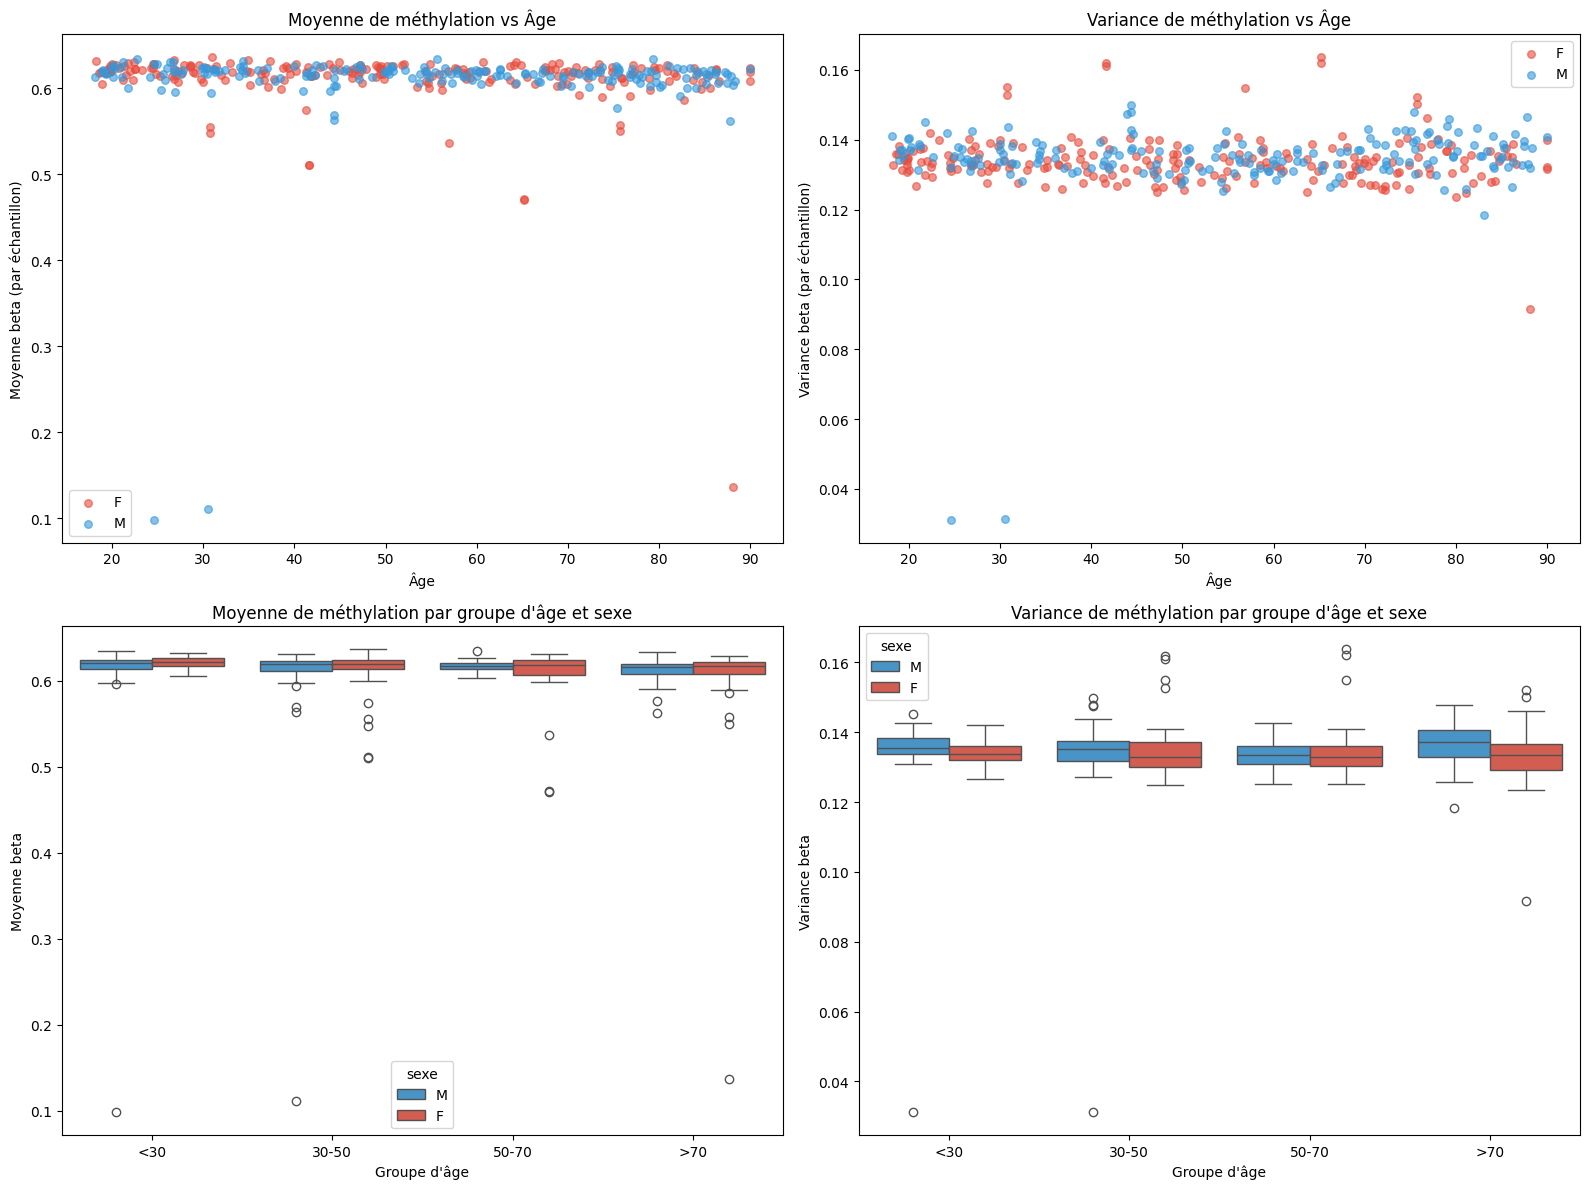

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Mean beta vs Age, coloré par sexe ---
ax = axes[0, 0]
for sexe, color in [('F', '#e74c3c'), ('M', '#3498db')]:
    mask = stats_df['sexe'] == sexe
    ax.scatter(stats_df.loc[mask, 'age'], stats_df.loc[mask, 'mean_beta'],
               alpha=0.6, label=sexe, color=color, s=30)
ax.set_xlabel('Âge')
ax.set_ylabel('Moyenne beta (par échantillon)')
ax.set_title('Moyenne de méthylation vs Âge')
ax.legend()

# --- Variance beta vs Age ---
ax = axes[0, 1]
for sexe, color in [('F', '#e74c3c'), ('M', '#3498db')]:
    mask = stats_df['sexe'] == sexe
    ax.scatter(stats_df.loc[mask, 'age'], stats_df.loc[mask, 'var_beta'],
               alpha=0.6, label=sexe, color=color, s=30)
ax.set_xlabel('Âge')
ax.set_ylabel('Variance beta (par échantillon)')
ax.set_title('Variance de méthylation vs Âge')
ax.legend()

# --- Boxplot mean beta par age_group et sexe ---
ax = axes[1, 0]
sns.boxplot(data=stats_df, x='age_group', y='mean_beta', hue='sexe',
            palette={'F': '#e74c3c', 'M': '#3498db'}, ax=ax)
ax.set_xlabel("Groupe d'âge")
ax.set_ylabel('Moyenne beta')
ax.set_title("Moyenne de méthylation par groupe d'âge et sexe")

# --- Boxplot variance par age_group et sexe ---
ax = axes[1, 1]
sns.boxplot(data=stats_df, x='age_group', y='var_beta', hue='sexe',
            palette={'F': '#e74c3c', 'M': '#3498db'}, ax=ax)
ax.set_xlabel("Groupe d'âge")
ax.set_ylabel('Variance beta')
ax.set_title("Variance de méthylation par groupe d'âge et sexe")

plt.tight_layout()
plt.savefig('results/eda_mean_var_by_age_sex.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Distribution des Niveaux de Méthylation par Âge et Sexe

Distribution globale des valeurs beta et distribution par sous-groupe.

In [7]:
# --- Histogramme des valeurs beta (échantillon de CpG pour mémoire) ---
print('Chargement d\'un échantillon de CpG pour les distributions...')
# Prendre 10000 CpG au hasard
np.random.seed(RANDOM_STATE)
sample_cpg_idx = np.sort(np.random.choice(n_cpg, size=10000, replace=False))

rows = []
start = 0
for chunk in pd.read_csv(data_path, usecols=common_ids, chunksize=CHUNK_SIZE):
    end = start + len(chunk)
    pos_s = np.searchsorted(sample_cpg_idx, start)
    pos_e = np.searchsorted(sample_cpg_idx, end)
    local = sample_cpg_idx[pos_s:pos_e] - start
    if len(local) > 0:
        rows.append(chunk.iloc[local].values)
    start = end

X_sample = np.vstack(rows).T.astype(np.float32)  # (400, 10000)
print(f'  Échantillon chargé : {X_sample.shape}')

ages = ind.loc[common_ids, 'age'].values
sexes = ind.loc[common_ids, 'sexe'].values
age_groups = ind.loc[common_ids, 'age_group'].values

Chargement d'un échantillon de CpG pour les distributions...
  Échantillon chargé : (400, 10000)


ValueError: autodetected range of [nan, nan] is not finite

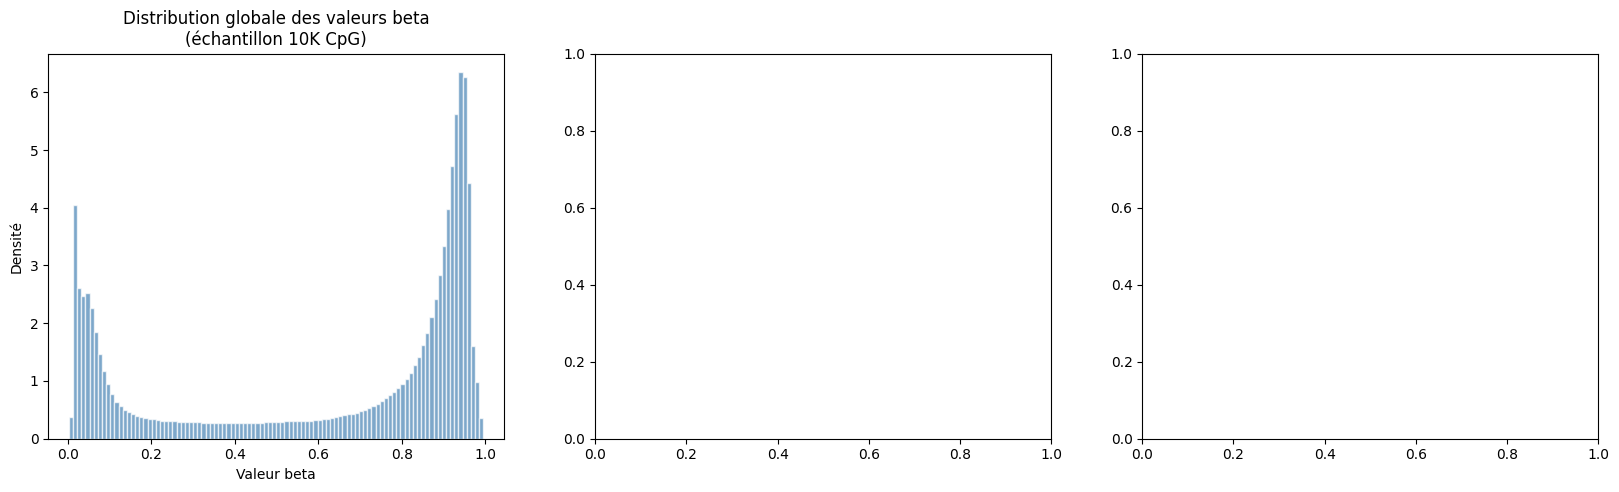

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- Distribution globale ---
ax = axes[0]
ax.hist(X_sample.flatten(), bins=100, density=True, alpha=0.7, color='steelblue', edgecolor='white')
ax.set_xlabel('Valeur beta')
ax.set_ylabel('Densité')
ax.set_title('Distribution globale des valeurs beta\n(échantillon 10K CpG)')

# --- Distribution par sexe (mean beta par échantillon) ---
ax = axes[1]
for sexe, color in [('F', '#e74c3c'), ('M', '#3498db')]:
    mask = sexes == sexe
    means = X_sample[mask].mean(axis=1)
    ax.hist(means, bins=25, density=True, alpha=0.6, label=sexe, color=color, edgecolor='white')
ax.set_xlabel('Moyenne beta par échantillon')
ax.set_ylabel('Densité')
ax.set_title('Distribution de la moyenne beta par sexe')
ax.legend()

# --- Violin plot par groupe d'âge ---
ax = axes[2]
data_violin = []
for ag in ['<30', '30-50', '50-70', '>70']:
    mask = age_groups == ag
    data_violin.append(X_sample[mask].mean(axis=1))
parts = ax.violinplot(data_violin, positions=range(4), showmeans=True, showmedians=True)
ax.set_xticks(range(4))
ax.set_xticklabels(['<30', '30-50', '50-70', '>70'])
ax.set_xlabel("Groupe d'âge")
ax.set_ylabel('Moyenne beta par échantillon')
ax.set_title("Distribution par groupe d'âge")

plt.tight_layout()
plt.savefig('results/eda_beta_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Distribution des Corrélations avec l'Âge par Sexe

On calcule la corrélation de chaque CpG avec l'âge, globalement et séparément par sexe.

In [11]:
# --- Corrélations globales et par sexe (par chunks) ---
import time
print('Calcul des corrélations CpG-âge par chunks...')
# t0 = time()

y_all = ind.loc[common_ids, 'age'].values.astype(np.float32)
sexe_arr = ind.loc[common_ids, 'sexe'].values
mask_f = sexe_arr == 'F'
mask_m = sexe_arr == 'M'

y_all_c = y_all - y_all.mean()
y_all_den = np.sqrt(np.sum(y_all_c**2))
y_f = y_all[mask_f]
y_f_c = y_f - y_f.mean()
y_f_den = np.sqrt(np.sum(y_f_c**2))
y_m = y_all[mask_m]
y_m_c = y_m - y_m.mean()
y_m_den = np.sqrt(np.sum(y_m_c**2))

corrs_all = []
corrs_f = []
corrs_m = []

for chunk in pd.read_csv(data_path, usecols=common_ids, chunksize=CHUNK_SIZE):
    x = chunk.to_numpy(dtype=np.float32)
    if np.isnan(x).any():
        row_means = np.nanmean(x, axis=1, keepdims=True)
        row_means = np.where(np.isnan(row_means), 0, row_means)
        x = np.where(np.isnan(x), row_means, x)
    
    # Global
    x_c = x - x.mean(axis=1, keepdims=True)
    num = x_c @ y_all_c
    den = np.sqrt(np.sum(x_c**2, axis=1)) * y_all_den
    corrs_all.append(np.divide(num, den, out=np.zeros_like(num), where=den != 0))
    
    # Femmes
    xf = x[:, mask_f]
    xf_c = xf - xf.mean(axis=1, keepdims=True)
    num_f = xf_c @ y_f_c
    den_f = np.sqrt(np.sum(xf_c**2, axis=1)) * y_f_den
    corrs_f.append(np.divide(num_f, den_f, out=np.zeros_like(num_f), where=den_f != 0))
    
    # Hommes
    xm = x[:, mask_m]
    xm_c = xm - xm.mean(axis=1, keepdims=True)
    num_m = xm_c @ y_m_c
    den_m = np.sqrt(np.sum(xm_c**2, axis=1)) * y_m_den
    corrs_m.append(np.divide(num_m, den_m, out=np.zeros_like(num_m), where=den_m != 0))

corrs_all = np.concatenate(corrs_all)
corrs_f = np.concatenate(corrs_f)
corrs_m = np.concatenate(corrs_m)

# print(f'  Calculé en {time()-t0:.1f}s ({len(corrs_all)} CpG)')
print(f'  |corr| > 0.5 : {(np.abs(corrs_all) > 0.5).sum()} CpG')
print(f'  |corr| > 0.7 : {(np.abs(corrs_all) > 0.7).sum()} CpG')
print(f'  |corr| > 0.9 : {(np.abs(corrs_all) > 0.9).sum()} CpG')

print(np.max(corrs_all), np.min(corrs_all))

Calcul des corrélations CpG-âge par chunks...
  |corr| > 0.5 : 4549 CpG
  |corr| > 0.7 : 233 CpG
  |corr| > 0.9 : 1 CpG
0.9276563 -0.8678193


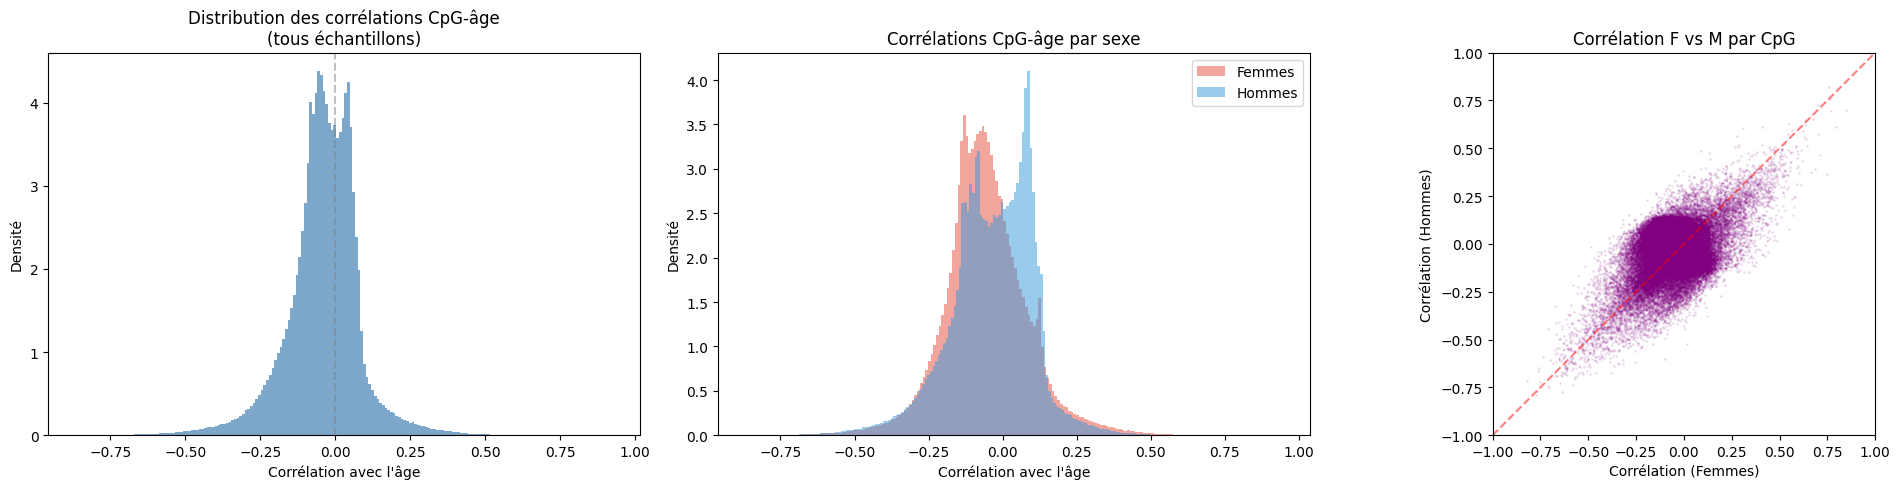

Corrélation entre corr_F et corr_M : 0.4648


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- Distribution globale des corrélations ---
ax = axes[0]
ax.hist(corrs_all, bins=200, density=True, alpha=0.7, color='steelblue', edgecolor='none')
ax.set_xlabel('Corrélation avec l\'âge')
ax.set_ylabel('Densité')
ax.set_title('Distribution des corrélations CpG-âge\n(tous échantillons)')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)

# --- Comparaison F vs M ---
ax = axes[1]
ax.hist(corrs_f, bins=200, density=True, alpha=0.5, color='#e74c3c', label='Femmes', edgecolor='none')
ax.hist(corrs_m, bins=200, density=True, alpha=0.5, color='#3498db', label='Hommes', edgecolor='none')
ax.set_xlabel('Corrélation avec l\'âge')
ax.set_ylabel('Densité')
ax.set_title('Corrélations CpG-âge par sexe')
ax.legend()

# --- Scatter corr F vs corr M ---
ax = axes[2]
# Sous-échantillonner pour la visu
idx_sub = np.random.choice(len(corrs_all), size=min(50000, len(corrs_all)), replace=False)
ax.scatter(corrs_f[idx_sub], corrs_m[idx_sub], alpha=0.1, s=1, color='purple')
ax.plot([-1, 1], [-1, 1], 'r--', alpha=0.5)
ax.set_xlabel('Corrélation (Femmes)')
ax.set_ylabel('Corrélation (Hommes)')
ax.set_title('Corrélation F vs M par CpG')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('results/eda_correlation_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Corrélation entre les corrélations F et M
r_fm = np.corrcoef(corrs_f, corrs_m)[0, 1]
print(f'Corrélation entre corr_F et corr_M : {r_fm:.4f}')

## 4. Réduction de Dimension (PCA, t-SNE, UMAP)

On utilise les top-500 CpG les plus corrélés avec l'âge pour la visualisation.

In [ ]:
# --- Charger les top-k CpG ---
print(f'Chargement des top {TOP_K} CpG pour réduction de dimension...')
t0 = time()
top_indices = np.argsort(np.abs(corrs_all))[::-1][:TOP_K]
indices_to_load = np.sort(top_indices)

rows = []
start = 0
for chunk in pd.read_csv(data_path, usecols=common_ids, chunksize=CHUNK_SIZE):
    end = start + len(chunk)
    pos_s = np.searchsorted(indices_to_load, start)
    pos_e = np.searchsorted(indices_to_load, end)
    local = indices_to_load[pos_s:pos_e] - start
    if len(local) > 0:
        rows.append(chunk.iloc[local].values)
    start = end

X_top = np.vstack(rows).T.astype(np.float32)  # (400, TOP_K)
print(f'  Chargé en {time()-t0:.1f}s, shape={X_top.shape}')

Chargement des top 500 CpG pour réduction de dimension...


  Chargé en 17.1s, shape=(400, 500)


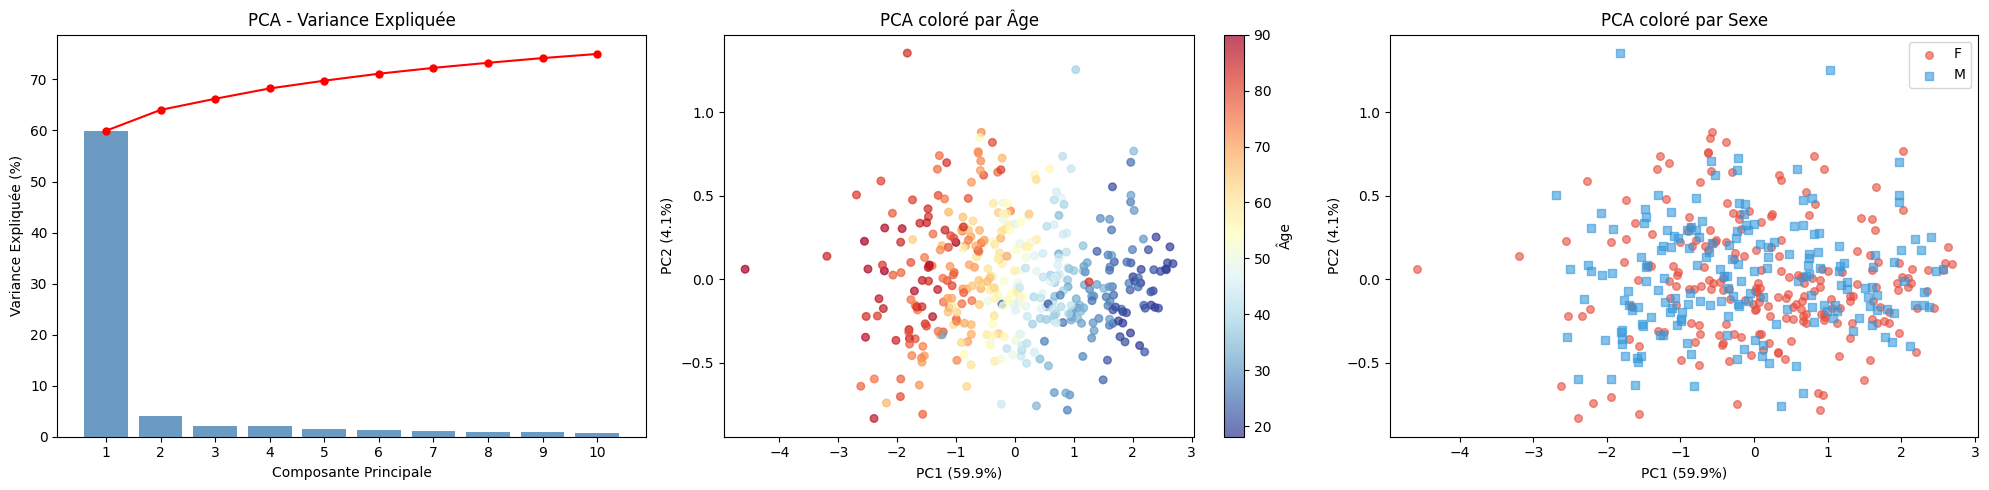

Variance cumulée (10 PC) : 75.0%


In [ ]:
# --- PCA ---
pca = PCA(n_components=10, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_top)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Variance expliquée
ax = axes[0]
ax.bar(range(1, 11), pca.explained_variance_ratio_ * 100, color='steelblue', alpha=0.8)
ax.plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_) * 100, 'ro-', markersize=5)
ax.set_xlabel('Composante Principale')
ax.set_ylabel('Variance Expliquée (%)')
ax.set_title('PCA - Variance Expliquée')
ax.set_xticks(range(1, 11))

# PC1 vs PC2, coloré par âge
ax = axes[1]
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=ages, cmap='RdYlBu_r', s=30, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Âge')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA coloré par Âge')

# PC1 vs PC2, coloré par sexe
ax = axes[2]
for sexe, color, marker in [('F', '#e74c3c', 'o'), ('M', '#3498db', 's')]:
    mask = sexes == sexe
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=sexe,
               s=30, alpha=0.6, marker=marker)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA coloré par Sexe')
ax.legend()

plt.tight_layout()
plt.savefig('results/eda_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Variance cumulée (10 PC) : {np.sum(pca.explained_variance_ratio_)*100:.1f}%')

t-SNE en cours...


  t-SNE terminé en 0.7s


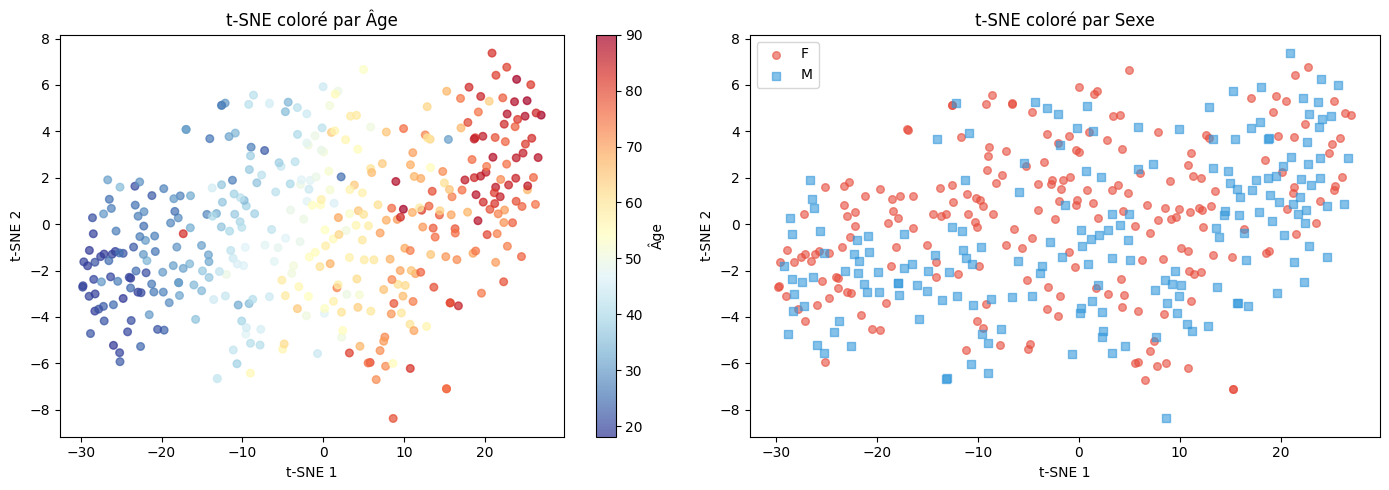

In [ ]:
# --- t-SNE ---
print('t-SNE en cours...')
t0 = time()
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, max_iter=1000)
X_tsne = tsne.fit_transform(X_top)
print(f'  t-SNE terminé en {time()-t0:.1f}s')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coloré par âge
ax = axes[0]
sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=ages, cmap='RdYlBu_r', s=30, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Âge')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE coloré par Âge')

# Coloré par sexe
ax = axes[1]
for sexe, color, marker in [('F', '#e74c3c', 'o'), ('M', '#3498db', 's')]:
    mask = sexes == sexe
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, label=sexe,
               s=30, alpha=0.6, marker=marker)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE coloré par Sexe')
ax.legend()

plt.tight_layout()
plt.savefig('results/eda_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- UMAP ---
if HAS_UMAP:
    print('UMAP en cours...')
    t0 = time()
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
    X_umap = reducer.fit_transform(X_top)
    print(f'  UMAP terminé en {time()-t0:.1f}s')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax = axes[0]
    sc = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=ages, cmap='RdYlBu_r', s=30, alpha=0.7)
    plt.colorbar(sc, ax=ax, label='Âge')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title('UMAP coloré par Âge')
    
    ax = axes[1]
    for sexe, color, marker in [('F', '#e74c3c', 'o'), ('M', '#3498db', 's')]:
        mask = sexes == sexe
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1], c=color, label=sexe,
                   s=30, alpha=0.6, marker=marker)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title('UMAP coloré par Sexe')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('results/eda_umap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('UMAP non disponible. Installer avec : pip install umap-learn')

UMAP non disponible. Installer avec : pip install umap-learn


## Résumé

In [ ]:
print('=' * 60)
print('  RÉSUMÉ DE L\'ANALYSE EXPLORATOIRE')
print('=' * 60)
print(f'\n  Échantillons : {len(common_ids)}')
print(f'  CpG sites : {n_cpg}')
print(f'  Âge : {ages.mean():.1f} ± {ages.std():.1f} ({ages.min():.0f} - {ages.max():.0f})')
print(f'  Sexe : {(sexes=="F").sum()} F, {(sexes=="M").sum()} M')
print(f'\n  CpG fortement corrélés avec l\'âge :')
print(f'    |r| > 0.5 : {(np.abs(corrs_all) > 0.5).sum()}')
print(f'    |r| > 0.7 : {(np.abs(corrs_all) > 0.7).sum()}')
print(f'    |r| > 0.9 : {(np.abs(corrs_all) > 0.9).sum()}')
print(f'  Corrélation F-M : {r_fm:.4f}')
print(f'  PCA variance (10 PC) : {np.sum(pca.explained_variance_ratio_)*100:.1f}%')
print(f"\n{'='*60}")

  RÉSUMÉ DE L'ANALYSE EXPLORATOIRE

  Échantillons : 400
  CpG sites : 894006
  Âge : 53.0 ± 21.2 (18 - 90)
  Sexe : 214 F, 186 M

  CpG fortement corrélés avec l'âge :
    |r| > 0.5 : 4549
    |r| > 0.7 : 233
    |r| > 0.9 : 1
  Corrélation F-M : 0.4648
  PCA variance (10 PC) : 75.0%

